In [3]:
import numpy as np
import pandas as pd

In [6]:
np.random.seed(0)
muestras = 100

# Generar 100 instancias para X1, X2, X3 y X5
X1 = np.random.randint(0, 2, muestras)
X2 = np.random.randint(0, 2, muestras)
X3 = np.random.randint(0, 2, muestras)
X5 = np.random.randint(0, 2, muestras)

# Calcular Y como XOR de X1, X2, X3
Y = X1 ^ X2 ^ X3

# Calcular X4 como XOR de X2, X3
X4 = X2 ^ X3

# Crear el DataFrame
data = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'X5': X5, 'Y': Y})

# Guardar los datos en un archivo CSV
# data.to_csv('synthetic_dataset.csv', index=False)

data.head()

,X1,X2,X3,X4,X5,Y
0,1,1,0,1,0,0
1,1,1,0,1,1,0
2,0,1,0,1,0,1
3,0,0,0,0,0,0
4,1,0,1,1,0,0


# Tecnicas

## Información mutua

In [4]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import mutual_info_score

# Separar variables predictoras y objetivo
X = data.drop(columns=['Y'])  
y = data['Y']

# Calcular información mutua
mi_scores = mutual_info_classif(X, y, discrete_features=True)

# Crear un DataFrame con los resultados
mi_results = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi_scores})
mi_results = mi_results.sort_values(by='Mutual Information', ascending=False)

# Mostrar los resultados
print("Ranking por Información Mutua:")
print(mi_results)


Ranking por Información Mutua:
  Feature  Mutual Information
3      X4            0.006485
1      X2            0.000694
2      X3            0.000123
0      X1            0.000067
4      X5            0.000035


## Chi2

In [5]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

X = data.drop(columns=['Y'])  
y = data['Y']

# Normalizar los datos a valores positivos para el test chi2
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar test chi2
chi2_scores, p_values = chi2(X_scaled, y)

# Crear un DataFrame con los resultados
chi2_results = pd.DataFrame({'Feature': X.columns, 'Chi2 Score': chi2_scores, 'p-value': p_values})
chi2_results = chi2_results.sort_values(by='Chi2 Score', ascending=False)

# Mostrar los resultados
print("Ranking por Test de Chi-Cuadrado:")
print(chi2_results)


Ranking por Test de Chi-Cuadrado:
  Feature  Chi2 Score   p-value
3      X4    0.621784  0.430385
1      X2    0.076401  0.782236
2      X3    0.012018  0.912707
0      X1    0.005942  0.938555
4      X5    0.002830  0.957577


## Relief

In [6]:
from skrebate import ReliefF

X = data.drop(columns=['Y'])  
y = data['Y']

# Aplicar ReliefF
relief = ReliefF(n_neighbors=10)  # Número de vecinos a considerar
relief.fit(X.values, y.values)

# Crear un DataFrame con los resultados
relief_results = pd.DataFrame({'Feature': X.columns, 'Relief Score': relief.feature_importances_})
relief_results = relief_results.sort_values(by='Relief Score', ascending=False)

# Mostrar los resultados
print("Ranking por Relief:")
print(relief_results)


Ranking por Relief:
  Feature  Relief Score
0      X1         0.688
3      X4         0.306
2      X3         0.123
1      X2         0.085
4      X5        -0.217


In [10]:
from skrebate import ReliefF

# Configurar ReliefF
relief = ReliefF(
    n_neighbors=10,        # Semilla para reproducibilidad
    discrete_threshold=10,  # Tratar todas las variables como discretas (booleanas)
)

# Ajustar el modelo y calcular los pesos
relief.fit(X.values, y.values)

# Crear DataFrame con los resultados
relief_df = pd.DataFrame({
    'Feature': X.columns,
    'Relief Score': relief.feature_importances_
}).sort_values(by='Relief Score', ascending=False)

relief_df

,Feature,Relief Score
0,X1,0.688
3,X4,0.306
2,X3,0.123
1,X2,0.085
4,X5,-0.217


## PCA

In [7]:
from sklearn.decomposition import PCA

X = data.drop(columns=['Y'])  
y = data['Y']

# Aplicar PCA
pca = PCA(n_components=5)  # Mantener el número total de características
pca.fit(X)

# Crear un DataFrame con la varianza explicada por cada componente
pca_results = pd.DataFrame({'Feature': X.columns, 'Explained Variance': pca.explained_variance_ratio_})
pca_results = pca_results.sort_values(by='Explained Variance', ascending=False)

# Mostrar los resultados
print("Ranking por PCA:")
print(pca_results)


Ranking por PCA:
  Feature  Explained Variance
0      X1            0.248424
1      X2            0.229504
2      X3            0.190220
3      X4            0.172384
4      X5            0.159468


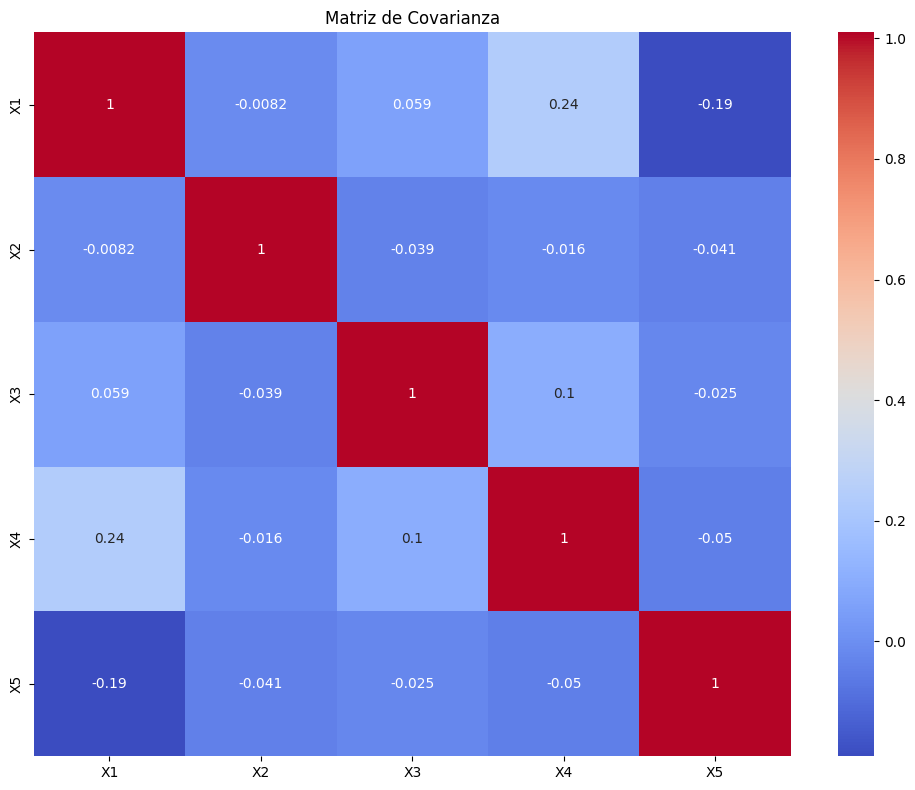

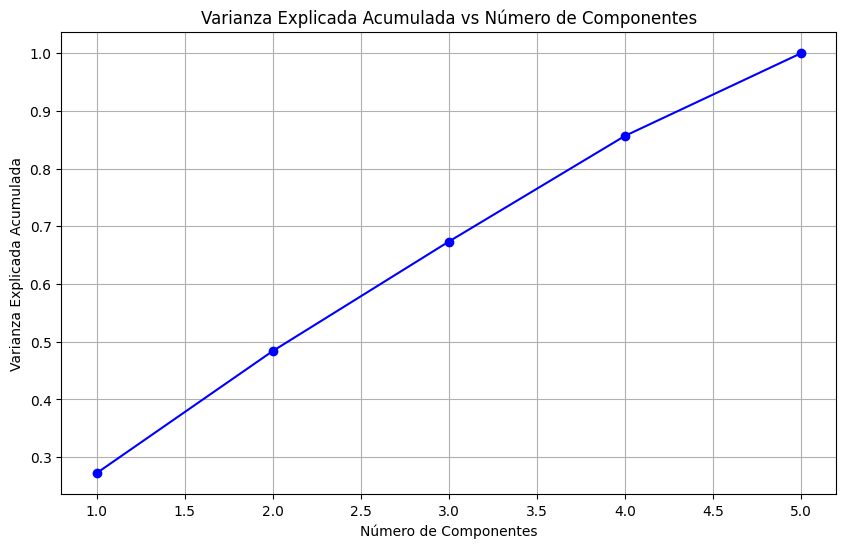

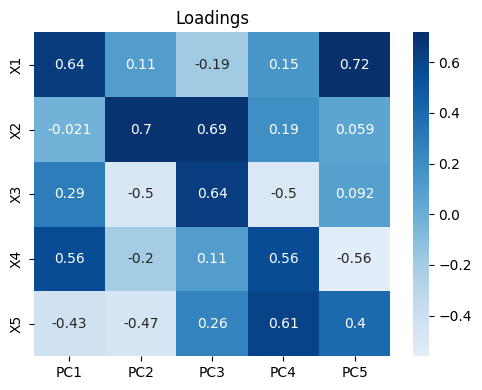

In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_pca(data):
    """
    Realiza un análisis PCA completo sobre el dataset proporcionado
    
    Parameters:
    data (pandas.DataFrame): DataFrame con las variables X1, X2, X3, X4, X5
    
    Returns:
    dict: Diccionario con los resultados del análisis
    """
    # 1. Preparación de los datos
    X = data[['X1', 'X2', 'X3', 'X4', 'X5']]
    
    # 2. Estandarización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. Cálculo de la matriz de covarianza
    cov_matrix = np.cov(X_scaled.T)
    
    # 4. Aplicación de PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # 5. Análisis de componentes principales
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    # 6. Obtención de los loadings (pesos de las variables)
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(X.shape[1])],
        index=X.columns
    )
    
    # 7. Visualizaciones
    
    # 7.1 Matriz de covarianza
    plt.figure(figsize=(10, 8))
    sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', 
                xticklabels=X.columns, yticklabels=X.columns)
    plt.title('Matriz de Covarianza')
    plt.tight_layout()
    plt.show()
    
    # 7.2 Varianza explicada
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance_ratio) + 1), 
            cumulative_variance_ratio, 'bo-')
    plt.xlabel('Número de Componentes')
    plt.ylabel('Varianza Explicada Acumulada')
    plt.title('Varianza Explicada Acumulada vs Número de Componentes')
    plt.grid(True)
    plt.show()
    
    # 7.3 Loadings de las variables
    plt.figure(figsize=(5, 4))
    sns.heatmap(loadings, annot=True, cmap='Blues', center=0)
    plt.title('Loadings')
    plt.tight_layout()
    plt.show()
    
    return {
        'explained_variance_ratio': explained_variance_ratio,
        'cumulative_variance_ratio': cumulative_variance_ratio,
        'loadings': loadings,
        'pca_scores': X_pca
    }

# Ejemplo de uso
resultados = analizar_pca(data)

In [12]:
resultados

{'explained_variance_ratio': array([0.27211193, 0.21162251, 0.18979821, 0.18314671, 0.14332063]),
 'cumulative_variance_ratio': array([0.27211193, 0.48373445, 0.67353266, 0.85667937, 1.        ]),
 'loadings':          PC1       PC2       PC3       PC4       PC5
 X1  0.643051  0.108809 -0.192656  0.149371  0.717787
 X2 -0.021194  0.695879  0.689429  0.191148  0.058767
 X3  0.289887 -0.495296  0.640276 -0.502270  0.091752
 X4  0.562270 -0.201003  0.111855  0.562947 -0.560383
 X5 -0.431108 -0.467112  0.255158  0.609890  0.398598,
 'pca_scores': array([[-1.4019718 , -0.01110267,  1.6990483 , -0.53747605,  0.25385032],
        [ 0.23619915,  0.75360892, -1.8765214 , -0.86097166,  0.58457211],
        [ 1.06153307, -1.59299628,  0.14901429,  0.50601536,  0.46008435],
        [ 0.02357602,  1.53084846,  0.12128908,  0.34912962, -1.86498992],
        [ 0.23619915,  0.75360892, -1.8765214 , -0.86097166,  0.58457211],
        [ 1.06153307, -1.59299628,  0.14901429,  0.50601536,  0.46008435],
  

In [14]:
pca.explained_variance_

array([0.3389604 , 0.26358771, 0.23795544, 0.22711384, 0.17824119])

## RFE-SVM

In [30]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

X = data.drop(columns=['Y'])  
y = data['Y']

# Definir el modelo SVM
svm = SVC(kernel="linear")

# Aplicar RFE
rfe = RFE(estimator=svm, n_features_to_select=1)  # Para obtener el ranking completo
rfe.fit(X, y)

# Crear un DataFrame con los rankings
rfe_results = pd.DataFrame({'Feature': X.columns, 'RFE Ranking': rfe.ranking_})
rfe_results = rfe_results.sort_values(by='RFE Ranking')

# Mostrar los resultados
print("Ranking por RFE-SVM:")
print(rfe_results)


Ranking por RFE-SVM:
  Feature  RFE Ranking
3      X4            1
0      X1            2
2      X3            3
1      X2            4
4      X5            5


In [35]:
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

X = data.drop(columns=['Y'])  
y = data['Y']
# Configurar SVM como modelo base
svm_model = SVC(
    kernel='linear',  # Kernel lineal para interpretabilidad de coeficientes
    C=1.0,            # Parámetro de regularización (valor por defecto)
    random_state=42   # Reproducibilidad
)

# Configurar RFE
rfe_selector = RFE(
    estimator=svm_model,
    n_features_to_select=1,  # Seleccionar 1 característica para obtener un ranking completo
    step=1,                  # Eliminar 1 característica por iteración
    verbose=0                # Sin mensajes de registro
)

# Ajustar RFE a los datos
rfe_selector.fit(X, y)

# Crear DataFrame con los resultados
rfe_df = pd.DataFrame({
    'Feature': X.columns,
    'RFE Ranking': rfe_selector.ranking_  # 1 = mejor, 5 = peor
}).sort_values(by='RFE Ranking', ascending=True)

rfe_df

,Feature,RFE Ranking
3,X4,1
0,X1,2
2,X3,3
1,X2,4
4,X5,5
